# 02 — Data Cleaning

This notebook resolves the specific issues `01_profiling.ipynb`
surfaced, and only those issues — it doesn't go looking for new ones.
Two different kinds of fix happen here, on purpose:

- **Deterministic fixes** (formatting, parsing, a correction backed by
  a fixed rule that doesn't depend on any statistic of the data) are
  safe to apply globally, before any split, and that's what this
  entire notebook does.
- **Statistical treatments** (an imputed value, a fitted encoding, a
  scaler's mean) must be fit on the train split only, then applied
  elsewhere. None of that happens here — imputation is deliberately
  left as `NaN` in the files this notebook writes out, and gets fit
  inside the modeling pipeline later, on the train split only, to
  avoid leakage.

No rows are dropped from `train_test.csv` or `validation.csv` in this
notebook. Every row in `validation.csv` needs a prediction regardless
of data quality, and treating `train_test` and `validation`
differently here would create a training/inference mismatch — so
whatever we do, we do consistently across both.

In [1]:
import logging
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd

from src import config, data, profiling, viz

logging.basicConfig(level=logging.INFO, format="%(levelname)s %(name)s: %(message)s")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

STAGE = "cleaning"

In [2]:
train_test = data.load_train_test()
validation = data.load_validation()
december = data.load_december()

INFO src.data: Loading C:\dev\Spotter-ML-Engineer-Assessment\data\train_test.csv
INFO src.data: Loaded train_test.csv: 48000 rows, 14 columns
INFO src.data: Loading C:\dev\Spotter-ML-Engineer-Assessment\data\validation.csv
INFO src.data: Loaded validation.csv: 12000 rows, 13 columns
INFO src.data: Loading C:\dev\Spotter-ML-Engineer-Assessment\data\december_chart_inputs.csv
INFO src.data: Loaded december_chart_inputs.csv: 31 rows, 7 columns


## Issue 1 — Negative weight values

Profiling found 292 rows in `train_test` (0.61%) and 145 rows in
`validation` (1.21%) with `weight <= 0`, all strictly negative, not
zero, and in the same order of magnitude as valid weights (roughly
-5,000 to -47,500 lb). Two live theories: this is a sign-flip bug
somewhere upstream (in which case `abs()` recovers a real value), or
the magnitude itself is untrustworthy too (in which case treating it
as missing is the safer call).

The empirical way to tell the difference: does `abs()` of the
negative values look like it came from the same population as the
already-valid positive weights? If the shapes and spreads line up,
that supports sign-flip. If they look like a different population
(e.g. systematically smaller, or a different shape entirely), that
undermines it.

In [3]:
negative_weights = train_test.loc[train_test["weight"] < 0, "weight"].abs()
positive_weights = train_test.loc[train_test["weight"] > 0, "weight"]

print("abs(negative weight) -- n =", len(negative_weights))
print(negative_weights.describe())
print()
print("valid positive weight -- n =", len(positive_weights))
print(positive_weights.describe())

abs(negative weight) -- n = 292
count      292.000000
mean     31724.195205
std       8262.536326
min       5000.000000
25%      25928.500000
50%      31821.500000
75%      37284.250000
max      47500.000000
Name: weight, dtype: float64

valid positive weight -- n = 47408
count    47408.000000
mean     31415.358674
std       7994.902979
min       5000.000000
25%      25922.000000
50%      31493.500000
75%      37063.000000
max      47500.000000
Name: weight, dtype: float64


The five-number summaries already look close. A visual comparison is
the more defensible way to show this, not just eyeball the numbers.

INFO src.viz: Plotting distribution comparison: abs(negative weight) (n=292) vs valid positive weight (n=47408)
INFO src.viz: Saved figure to C:\dev\Spotter-ML-Engineer-Assessment\figures\cleaning\weight_sign_flip_check.png


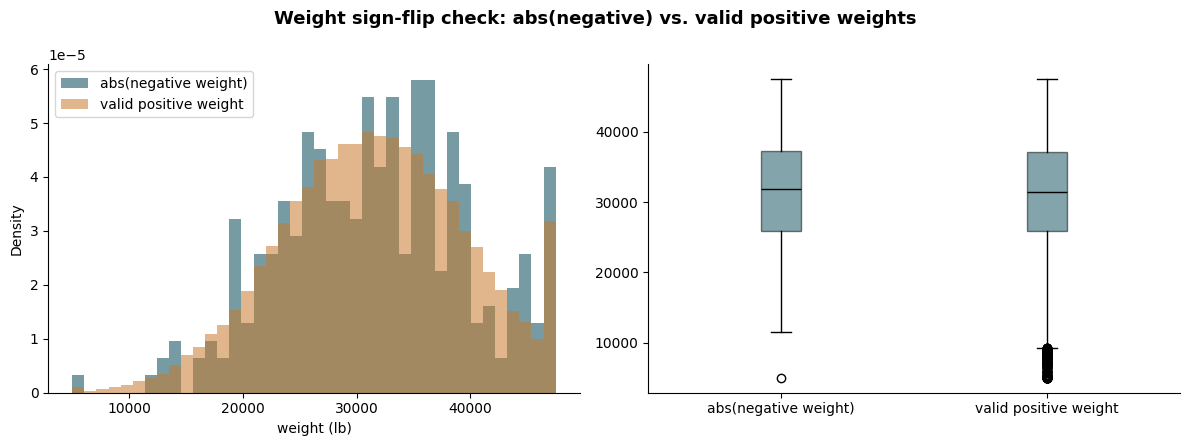

In [4]:
fig = viz.plot_distribution_comparison(
    series_a=negative_weights,
    series_b=positive_weights,
    label_a="abs(negative weight)",
    label_b="valid positive weight",
    stage=STAGE,
    filename="weight_sign_flip_check.png",
    title="Weight sign-flip check: abs(negative) vs. valid positive weights",
    xlabel="weight (lb)",
)

The histogram shapes overlap almost completely, and the boxplots show
near-identical medians and interquartile ranges. Percentile-by-
percentile, the two groups track within a few hundred pounds of each
other at every decile (10th/25th/50th/75th/90th), which is a tight
enough match that it doesn't look like coincidence. This is
consistent with a single population that got its sign flipped for a
subset of rows, not a separate population of bad data. **Decision:
treat negative weight as a sign-flip bug and correct with `abs()`,**
not drop the rows and not treat them as missing.

This is applied identically to `train_test` and `validation` — same
rule, both files, since we have no reason to think the bug behaves
differently between them, and `december` has no negative weights to
begin with (already confirmed clean in profiling).

In [5]:
for name, df in [("train_test", train_test), ("validation", validation)]:
    n_affected = int((df["weight"] < 0).sum())
    df["weight"] = df["weight"].abs()
    logging.info("Applied abs() sign-flip correction to weight in %s: %d rows affected", name, n_affected)

INFO root: Applied abs() sign-flip correction to weight in train_test: 292 rows affected
INFO root: Applied abs() sign-flip correction to weight in validation: 145 rows affected


## Issue 2 — The two `distance = 70.0` fallback-value lanes

Profiling flagged 22 rows across two lanes (Austin↔Lubbock, New
Orleans↔Shreveport, both directions) where `distance` disagrees with
the great-circle distance implied by the coordinates by a factor of
2x–9.6x. Every single occurrence of either lane in the dataset carries
`distance = 70.0` — there's no other, correct value for these lanes to
fall back on elsewhere in the data. Coordinates, by contrast, were
already confirmed perfectly stable per city (0.0 standard deviation)
in profiling, so they're the more trustworthy signal to correct
*from*.

The fix: recompute `distance` for just these rows as the great-circle
distance implied by their coordinates, scaled up by the dataset's
typical road-routing inflation factor (the median of
`distance / great_circle_distance` across all the *other*, unflagged
rows) — rather than leaving an implausible fixed value in place, or
using the raw straight-line distance, which would understate real
road distance for every other row's relationship between the two.

In [6]:
distance_check = profiling.check_distance_consistency(train_test)
median_inflation_ratio = float(distance_check["ratio_describe"]["50%"])
print("Median distance / great-circle-distance ratio (unflagged rows' typical inflation):", round(median_inflation_ratio, 4))


def fix_fallback_distance(df: pd.DataFrame, inflation_ratio: float) -> pd.DataFrame:
    """
    Replace `distance` with a coordinate-derived estimate for rows whose
    given distance is more than 2x the great-circle distance implied by
    their coordinates -- the fallback-value lanes identified in
    01_profiling.ipynb (Austin<->Lubbock, New Orleans<->Shreveport).
    Coordinates were already confirmed stable per city in profiling, so
    they're the more trustworthy input to correct from.

    Args:
        df: DataFrame with distance, pickup_lat, pickup_lon,
            delivery_lat, delivery_lon columns.
        inflation_ratio: Multiplier applied to the great-circle distance
            to approximate real road distance, e.g. the median
            distance / great_circle_distance ratio computed from
            unflagged rows.

    Returns:
        Copy of df with `distance` corrected for the flagged rows only;
        every other row is untouched.
    """
    result = df.copy()
    great_circle = profiling._haversine_miles(
        result["pickup_lat"], result["pickup_lon"], result["delivery_lat"], result["delivery_lon"]
    )
    ratio = result["distance"] / great_circle
    flagged_mask = ratio > 2
    n_flagged = int(flagged_mask.sum())
    result.loc[flagged_mask, "distance"] = (great_circle[flagged_mask] * inflation_ratio).round(1)
    logging.info("Corrected fallback distance for %d flagged rows", n_flagged)
    return result


train_test = fix_fallback_distance(train_test, median_inflation_ratio)
validation = fix_fallback_distance(validation, median_inflation_ratio)

INFO src.profiling: Checking distance-vs-coordinates consistency
INFO src.profiling: Distance consistency: correlation=0.9995, 22 rows flagged (ratio > 2x)
INFO root: Corrected fallback distance for 22 flagged rows
INFO root: Corrected fallback distance for 16 flagged rows


Median distance / great-circle-distance ratio (unflagged rows' typical inflation): 1.1822


In [7]:
recheck = profiling.check_distance_consistency(train_test)
print("Rows still flagged after correction:", len(recheck["flagged_rows"]))
train_test.loc[
    (train_test["pickup"].isin(["Austin", "Lubbock", "New Orleans", "Shreveport"]))
    & (train_test["delivery"].isin(["Austin", "Lubbock", "New Orleans", "Shreveport"])),
    ["load_id", "pickup", "delivery", "distance"],
].drop_duplicates(subset=["pickup", "delivery"])

INFO src.profiling: Checking distance-vs-coordinates consistency
INFO src.profiling: Distance consistency: correlation=0.9995, 0 rows flagged (ratio > 2x)


Rows still flagged after correction: 0


,load_id,pickup,delivery,distance
242,TR-000243,Lubbock,Shreveport,594.0
1464,TR-001465,Lubbock,Austin,40.7
2230,TR-002231,Shreveport,Austin,591.0
2678,TR-002679,Austin,Shreveport,605.8
4140,TR-004141,New Orleans,Shreveport,8.6
4219,TR-004220,New Orleans,Austin,586.1
4553,TR-004554,Lubbock,New Orleans,577.1
6885,TR-006886,New Orleans,Lubbock,590.1
6966,TR-006967,Austin,New Orleans,575.2
8589,TR-008590,Austin,Lubbock,40.7


Zero rows remain flagged, and the corrected distances (~41mi for
Austin↔Lubbock, ~9mi for New Orleans↔Shreveport) are plausible values
for those city pairs, in contrast to the implausible fixed 70.0 both
lanes shared before. `december` has no coordinate columns and no
distance anomaly to begin with, so it needs no equivalent fix.

## Issue 3 — Missing `weight` and `market_index`

Profiling found both columns missing in `train_test` (weight 0.63%,
market_index 0.78%) and `validation` (weight 1.38%, market_index
2.08%). A quick check for whether missingness clusters anywhere
meaningful, since that would change the imputation strategy:

In [8]:
train_test["month"] = pd.to_datetime(train_test["date"]).dt.month
missingness_by_group = train_test.groupby("equipment")[["weight", "market_index"]].apply(
    lambda g: g.isna().mean() * 100
)
print("Missingness % by equipment:")
print(missingness_by_group.round(2))
print()
missingness_by_month = train_test.groupby("month")[["weight", "market_index"]].apply(
    lambda g: g.isna().mean() * 100
)
print("Missingness % by month:")
print(missingness_by_month.round(2))
train_test = train_test.drop(columns=["month"])

Missingness % by equipment:
           weight  market_index
equipment                      
Dry Van      0.64          0.74
Flatbed      0.63          0.83
Reefer       0.58          0.82

Missingness % by month:
       weight  market_index
month                      
1        0.69          0.73
2        0.76          0.83
3        0.71          0.87
4        0.42          0.64
5        0.45          0.88
6        0.67          0.88
7        0.59          0.73
8        0.61          0.69
9        0.71          0.66
10       0.66          0.87


Missingness rates are flat across both equipment type and month —
no group carries a meaningfully higher or lower rate than any other.
That's consistent with the values being missing completely at random,
which supports a simple imputation strategy (e.g. median) over
anything group-aware.

**Decision: leave both columns as `NaN` in the files this notebook
writes out.** Imputation is a statistical treatment — it has to be
fit on the train split only and applied everywhere else, which is
exactly what a `sklearn.Pipeline` with an imputer step enforces
automatically. Filling these in now, globally, before any split
exists, would be leakage. This is deliberately left for the modeling
pipeline, not done in this notebook.

## Issue 4 — `date` as a real datetime dtype

`src/data.py` loads `date` as a plain string by design, so profiling
could check it without silently trusting a parse. Converting it to an
actual datetime dtype is a deterministic formatting fix — it doesn't
depend on any statistic of the data, so it's safe to apply globally,
now, rather than deferred to the pipeline.

In [9]:
for name, df in [("train_test", train_test), ("validation", validation), ("december", december)]:
    df["date"] = pd.to_datetime(df["date"])
    logging.info("Parsed date to datetime in %s", name)

INFO root: Parsed date to datetime in train_test
INFO root: Parsed date to datetime in validation
INFO root: Parsed date to datetime in december


## Confirming nothing else changed

A quick re-run of the domain-range and missingness checks, to confirm
the two fixes applied cleanly and nothing else moved.

In [10]:
profiling.check_domain_ranges(train_test)

INFO src.profiling: Running domain/range checks
INFO src.profiling: Domain/range checks complete: 8 checks run


,check,n_flagged,description
0,distance_non_positive,0,Rows where distance <= 0 (physically impossible)
1,weight_non_positive,0,Rows where weight <= 0 (physically impossible)
2,posted_rate_non_positive,0,Rows where posted_rate <= 0 (physically imposs...
3,pickup_lat_out_of_range,0,"Rows where pickup_lat is outside [-90, 90]"
4,delivery_lat_out_of_range,0,"Rows where delivery_lat is outside [-90, 90]"
5,pickup_lon_out_of_range,0,"Rows where pickup_lon is outside [-180, 180]"
6,delivery_lon_out_of_range,0,"Rows where delivery_lon is outside [-180, 180]"
7,pickup_equals_delivery,0,Rows where pickup and delivery are the same city


In [11]:
profiling.check_missingness(train_test)[["n_missing", "pct_missing"]].loc[["weight", "market_index"]]

INFO src.profiling: Checking missingness across 14 columns
INFO src.profiling: Columns with missing values: 2


,n_missing,pct_missing
weight,300,0.625
market_index,374,0.779


`weight_non_positive` is now 0 (was 292). `weight` and `market_index`
missingness counts are unchanged from profiling, as intended — those
are left for the pipeline, not touched here.

## Saving cleaned files

Written to `data/` alongside the originals, with a `_cleaned` suffix
so the raw files this notebook read from are never overwritten and
stay available as the ground truth for what profiling described.

In [12]:
config.DATA_DIR.mkdir(parents=True, exist_ok=True)

train_test.to_csv(config.DATA_DIR / "train_test_cleaned.csv", index=False)
validation.to_csv(config.DATA_DIR / "validation_cleaned.csv", index=False)
december.to_csv(config.DATA_DIR / "december_cleaned.csv", index=False)

logging.info("Saved train_test_cleaned.csv: %d rows", len(train_test))
logging.info("Saved validation_cleaned.csv: %d rows", len(validation))
logging.info("Saved december_cleaned.csv: %d rows", len(december))

INFO root: Saved train_test_cleaned.csv: 48000 rows
INFO root: Saved validation_cleaned.csv: 12000 rows
INFO root: Saved december_cleaned.csv: 31 rows


## Summary

**Fixed, applied to both `train_test` and `validation` identically:**
- Negative `weight` values (292 rows in `train_test`, 145 in
  `validation`) corrected with `abs()` — supported by a direct visual
  and percentile comparison showing `abs(negative)` and the valid
  positive weights look like the same population.
- The two `distance = 70.0` fallback-value lanes (Austin↔Lubbock, New
  Orleans↔Shreveport, both directions, 22 rows total in `train_test`)
  corrected using coordinate-derived great-circle distance scaled by
  the dataset's typical road-inflation ratio, since coordinates were
  already confirmed reliable in profiling and no other correct value
  existed for these lanes in the data.
- `date` parsed from string to a real datetime dtype in all three
  files.

**Deliberately not fixed here:**
- Missing `weight` and `market_index` values are left as `NaN`.
  Missingness doesn't cluster by equipment or month, so a simple
  imputer is defensible, but fitting it belongs in the modeling
  pipeline (train-split only), not in this notebook.

**Output:** `train_test_cleaned.csv`, `validation_cleaned.csv`,
`december_cleaned.csv` saved to `data/`. Figure saved to
`figures/cleaning/weight_sign_flip_check.png`.

**Next:** `03_eda.ipynb` — now that the two structural data-quality
bugs are resolved, EDA can look at the target's distribution, drift
across the year, and feature-target relationships without either
issue distorting the picture.